# CSE5280 Assignment: Evacuation Simulation (Three-Floor Building)
**Author:** Braiden Ames
**Date:** 2-23-2026

---

## 1. Overview

This assignment extends the multi-particle cost-function framework into a full 3-D three-floor building evacuation simulation.  All motion emerges from minimising a scalar cost function — no collision detection, no path-planning algorithms, and no rule-based floor switching.  Vertical transitions are handled by two ramps modelled as geometric surface patches; the cost function penalises deviation from those surfaces so particles naturally descend to the ground floor and exit through one of two exits chosen via a soft-min formulation.

**Key design choices:**
* Ramp height follows the linear projection formula from the assignment specification.
* Surface-adherence cost uses a quadratic penalty weighted by `w_height`.
* Goal attraction uses the soft-min of two squared distances (temperature τ).
* Wall repulsion uses a log-barrier penalty.
* Agent repulsion uses a short-range quadratic repulsion.
* Smoothness term penalises large jumps between iterations.
* Gradient is approximated by central finite differences in all three dimensions.

---

## 2. Building Model

### 2.1 Dimensions and Floors

| Floor | z-height |
|-------|----------|
| Ground | 0.0 |
| First  | H = 4.0 |
| Second | 2H = 8.0 |

Each floor is a 12 × 10 rectangular room subdivided by interior walls to form a
sufficiently challenging layout (L-shaped corridors, a central dividing wall, and a
side alcove).  Back walls are taller to frame the scene; interior walls are lower so
agents remain visible from the camera.

### 2.2 Floor Transitions

Two ramps connect:
* **Ramp A** – second floor (z = 2H) → first floor (z = H)
* **Ramp B** – first floor  (z = H)  → ground floor (z = 0)
Each ramp is a capsule corridor with half-width `r_ramp = 0.9`.

### 2.3 Two Exits

* Exit 1 at the south-west corner of the ground floor
* Exit 2 at the south-east corner of the ground floor

Exit assignment is never hard-coded; the soft-min goal cost lets each agent
gravitate toward whichever exit is currently cheaper.

---

## 3. Theory

### 3.1 Ramp Height Function

For a ramp with centreline endpoints $A$, $B$ connecting floors at $z_0$ and $z_1$:

$$t = \frac{(P - A) \cdot v}{v \cdot v}, \quad v = B - A$$

$$u(x,y) = \operatorname{clip}(t, 0, 1)$$

$$z_\text{ramp}(x,y) = z_0 + (z_1 - z_0)\, u(x,y)$$

The ramp footprint is a capsule of half-width $r$:

$$\mathcal{R} = \{(x,y) \mid \operatorname{dist}((x,y), [A,B]) \le r\}$$

### 3.2 Surface Height

$$z_\text{surf}(x,y) = (1 - g)\, z_\text{floor} + g\, z_\text{ramp}(x,y)$$

where $g = 1$ inside the ramp footprint and $g = 0$ outside.

### 3.3 Total Cost

$$C = C_\text{goal} + C_\text{walls} + C_\text{height} + C_\text{smooth} + C_\text{repulsion}$$

**Goal (soft-min):**

$$C_\text{goal}(p) = -\tau \log\!\left(\sum_{i=1}^{2} \exp\!\left(-\frac{\|p - p_i^\text{exit}\|^2}{\tau}\right)\right)$$

Gradient: $\nabla C_\text{goal} = \sum_i w_i \nabla C_i$, where
$w_i = \exp(-C_i/\tau)\big/\sum_j \exp(-C_j/\tau)$.  Recommended $\tau \in [0.5, 1.5]$.

**Height:**

$$C_\text{height} = w_h\,(z - z_\text{surf}(x,y))^2$$

**Walls** (log-barrier):

$$\phi(d) = \log\!\left(\frac{R}{d + \varepsilon}\right), \quad d \le R$$

**Repulsion:**

$$C_\text{repulsion} = \sum_{j \neq i} \phi(\|p_i - p_j\|), \quad \phi(d) = \tfrac{1}{2}(R_s - d)^2 \text{ for } d \le R_s$$

**Smoothness:**

$$C_\text{smooth} = \|p^{(k+1)} - p^{(k)}\|^2$$

---

## 4. Implementation

In [ ]:
import numpy as np
import os, glob, subprocess
from IPython.display import HTML
from base64 import b64encode

# ── Building dimensions ──────────────────────────────────────────────────────
H       = 4.0          # floor-to-floor height
FLOOR_Z = [0.0, H, 2*H]   # z of ground / first / second floors
W, D    = 12.0, 10.0  # floor width (x) and depth (y)
RAMP_R  = 0.9          # ramp half-width (capsule radius)

# ── Simulation parameters ─────────────────────────────────────────────────────
N_PARTICLES = 24
STEPS       = 900
DT          = 0.03
ALPHA_SMOOTH = 0.25    # EMA for velocity

# ── Cost weights ──────────────────────────────────────────────────────────────
W_WALL    = 12.0
W_HEIGHT  = 60.0
W_REPULS  = 4.0
W_SMOOTH  = 0.5
TAU       = 1.0        # soft-min temperature
WALL_R    = 0.9        # wall influence radius
SOCIAL_R  = 1.2        # repulsion radius
MAX_GRAD  = 25.0       # gradient clipping

# ── Exit tolerance ────────────────────────────────────────────────────────────
EXIT_TOL  = 0.8

In [ ]:
# Each floor has a list of wall segments as (a, b) pairs (2-D, in XY plane).
# Origin is at the SW corner of the building on each floor.
# Outer walls are shared; interior walls differ per floor.

def make_floor_walls():
    """
    Returns dict with keys 0, 1, 2 (floor index), each a list of
    (np.array([x0,y0]), np.array([x1,y1])) wall segments.

    Ground floor  – two exits (gaps in the south wall)
    First floor   – L-shaped interior partition
    Second floor  – central dividing wall with a corridor gap
    """
    walls = {}

    # ── Ground floor (floor 0) ────────────────────────────────────────────────
    # Outer boundary with two exit gaps in the south wall.
    # South wall: x in [0, W], gap 1 at [1.5, 2.5], gap 2 at [9.5, 10.5]
    g0 = [
        # South wall (bottom), with two exit gaps
        ([ 0,  0], [ 1.5, 0]),
        ([ 2.5, 0], [ 9.5, 0]),
        ([10.5, 0], [W,    0]),
        # North wall (top)
        ([ 0,  D], [W,    D]),
        # West wall
        ([ 0,  0], [ 0,   D]),
        # East wall
        ([W,   0], [W,    D]),
        # Interior: horizontal partition at y=5, gap at x=[5,7]
        ([ 0,   5], [ 5,   5]),
        ([ 7,   5], [W,    5]),
        # Interior: vertical stub at x=6, from y=5 to y=8
        ([ 6,   5], [ 6,   8]),
    ]
    walls[0] = [(np.array(a, float), np.array(b, float)) for a, b in g0]

    # ── First floor (floor 1) ─────────────────────────────────────────────────
    g1 = [
        # Outer boundary (no exits)
        ([ 0,  0], [W,    0]),
        ([ 0,  D], [W,    D]),
        ([ 0,  0], [ 0,   D]),
        ([W,   0], [W,    D]),
        # Interior: L-shaped partition
        ([ 3,  0], [ 3,   6]),
        ([ 3,  6], [ 8,   6]),
        # Small alcove stub
        ([ 8,  6], [ 8,   9]),
    ]
    walls[1] = [(np.array(a, float), np.array(b, float)) for a, b in g1]

    # ── Second floor (floor 2) ────────────────────────────────────────────────
    g2 = [
        # Outer boundary
        ([ 0,  0], [W,    0]),
        ([ 0,  D], [W,    D]),
        ([ 0,  0], [ 0,   D]),
        ([W,   0], [W,    D]),
        # Interior: central east-west wall with gap at x=[4.5, 6.5]
        ([ 0,  5], [ 4.5, 5]),
        ([ 6.5, 5], [W,   5]),
        # North room divider
        ([ 9,  5], [ 9,  D]),
    ]
    walls[2] = [(np.array(a, float), np.array(b, float)) for a, b in g2]

    return walls


FLOOR_WALLS = make_floor_walls()

# ── Exits (ground floor, 3-D positions) ───────────────────────────────────────
EXIT1 = np.array([ 2.0, 0.0, 0.0])   # south-west exit
EXIT2 = np.array([10.0, 0.0, 0.0])   # south-east exit
EXITS = [EXIT1, EXIT2]

In [ ]:
# Ramp B: first floor → ground floor
# Centreline from (x=5, y=1) on ground floor to (x=5, y=4) on first floor.
RAMP_B = dict(
    A     = np.array([5.0, 1.0]),   # xy on ground floor (z=z0)
    B     = np.array([5.0, 4.5]),   # xy on first floor  (z=z1)
    z0    = FLOOR_Z[0],             # height at A
    z1    = FLOOR_Z[1],             # height at B
    r     = RAMP_R,
    floor_below = 0,
    floor_above = 1,
)

# Ramp A: second floor → first floor
# Centreline from (x=7, y=5.5) on first floor to (x=7, y=9) on second floor.
RAMP_A = dict(
    A     = np.array([7.0, 5.5]),   # xy on first floor  (z=z0)
    B     = np.array([7.0, 9.0]),   # xy on second floor (z=z1)
    z0    = FLOOR_Z[1],
    z1    = FLOOR_Z[2],
    r     = RAMP_R,
    floor_below = 1,
    floor_above = 2,
)

RAMPS = [RAMP_A, RAMP_B]

In [ ]:
def point_to_segment_dist_2d(p, a, b):
    """Minimum distance from 2-D point p to segment [a, b]."""
    v = b - a
    w = p - a
    vv = np.dot(v, v)
    if vv < 1e-12:
        return np.linalg.norm(p - a)
    t = np.clip(np.dot(w, v) / vv, 0.0, 1.0)
    return np.linalg.norm(p - (a + t * v))


def ramp_u(xy, ramp):
    """Normalised coordinate along ramp centreline (0 at A, 1 at B)."""
    A, B = ramp["A"], ramp["B"]
    v = B - A
    vv = np.dot(v, v)
    if vv < 1e-12:
        return 0.0
    t = np.dot(xy - A, v) / vv
    return float(np.clip(t, 0.0, 1.0))


def ramp_height(xy, ramp):
    """Height of ramp surface at 2-D position xy (inside footprint only)."""
    u = ramp_u(xy, ramp)
    return ramp["z0"] + (ramp["z1"] - ramp["z0"]) * u


def in_ramp_footprint(xy, ramp):
    """True if xy is inside the ramp capsule footprint."""
    return point_to_segment_dist_2d(xy, ramp["A"], ramp["B"]) <= ramp["r"]


def surface_height(xy, floor_z):
    """
    Height of the building surface at 2-D position xy given the agent's
    nominal floor height floor_z.  Blends flat floor with any active ramp.
    """
    z_surf = floor_z
    for ramp in RAMPS:
        # Only activate the ramp when the agent is near the correct floor levels
        if in_ramp_footprint(xy, ramp):
            z_r = ramp_height(xy, ramp)
            # Smooth blend using the ramp's own u
            u = ramp_u(xy, ramp)
            # Use ramp height if agent is on the ramp corridor
            z_surf = z_r
            break
    return z_surf

In [ ]:
def wall_penalty(d, R=1.0, eps=0.05):
    """Truncated log-barrier wall penalty."""
    if d <= R:
        return np.log(R / (d + eps))
    return 0.0


def goal_softmin(p3, exits, tau=TAU):
    """
    Soft-min over squared distances to each exit.
    C_goal = -tau * log(sum_i exp(-||p - exit_i||^2 / tau))
    """
    costs = [np.sum((p3 - e) ** 2) for e in exits]
    # Numerically stable log-sum-exp
    c_arr = np.array(costs)
    c_max = c_arr.max()
    lse = c_max - tau * np.log(np.sum(np.exp(-(c_arr - c_max) / tau)))
    return lse


def height_cost(p3, floor_z, w=W_HEIGHT):
    """Penalise deviation from the building surface."""
    xy = p3[:2]
    z_surf = surface_height(xy, floor_z)
    return w * (p3[2] - z_surf) ** 2


def agent_repulsion(pi, pj, R=SOCIAL_R):
    """Quadratic repulsion between two agents."""
    d = np.linalg.norm(pi - pj)
    if d < 1e-9 or d > R:
        return 0.0
    return 0.5 * (R - d) ** 2


In [ ]:
def nearest_floor(z):
    """Return the index of the floor closest to z."""
    dists = [abs(z - fz) for fz in FLOOR_Z]
    return int(np.argmin(dists))


def agent_floor_z(p3):
    """
    Return the z of the floor on which the agent is currently standing.
    We pick the nearest floor whose level is ≤ agent z + small tolerance,
    falling back to the nearest floor if the agent is on a ramp.
    """
    xy = p3[:2]
    # Check if agent is on a ramp — use ramp's lower-floor z as reference
    for ramp in RAMPS:
        if in_ramp_footprint(xy, ramp):
            # The surface height at this xy is the ramp height
            return ramp_height(xy, ramp)
    # Otherwise snap to nearest flat floor
    return FLOOR_Z[nearest_floor(p3[2])]

In [ ]:
def total_cost(p3_try, i, positions, floor_z_i, walls_2d, exits):
    """
    Evaluate the total cost for agent i at trial position p3_try.

    Parameters
    ----------
    p3_try   : (3,) candidate position
    i        : agent index
    positions: (N, 3) current positions of all agents
    floor_z_i: nominal floor z for agent i (used for height cost)
    walls_2d : list of (a, b) 2-D wall segments (same for all floors combined)
    exits    : list of (3,) exit positions
    """
    c = 0.0

    # ── Goal (soft-min) ───────────────────────────────────────────────────────
    c += goal_softmin(p3_try, exits, tau=TAU)

    # ── Wall repulsion (applied per-floor walls for the relevant floor) ───────
    floor_idx = nearest_floor(p3_try[2])
    floor_walls = FLOOR_WALLS.get(floor_idx, [])
    xy_try = p3_try[:2]
    for a, b in floor_walls:
        d = point_to_segment_dist_2d(xy_try, a, b)
        c += W_WALL * wall_penalty(d, R=WALL_R)

    # ── Height adherence ──────────────────────────────────────────────────────
    z_surf = surface_height(xy_try, FLOOR_Z[nearest_floor(p3_try[2])])
    c += W_HEIGHT * (p3_try[2] - z_surf) ** 2

    # ── Agent repulsion ───────────────────────────────────────────────────────
    for j, pj in enumerate(positions):
        if j == i:
            continue
        c += W_REPULS * agent_repulsion(p3_try, pj)

    # ── Smoothness (penalise large step from current position) ────────────────
    c += W_SMOOTH * np.sum((p3_try - positions[i]) ** 2)

    return c


def gradient_3d(i, positions, exits, eps=1e-4):
    """
    Numerical gradient of total cost for agent i via central differences.
    Returns (3,) gradient vector, clipped to MAX_GRAD.
    """
    pi = positions[i]
    floor_z_i = FLOOR_Z[nearest_floor(pi[2])]
    walls_2d = []   # passed for signature compatibility (unused directly)
    grad = np.zeros(3)

    for dim in range(3):
        pp = pi.copy(); pp[dim] += eps
        pm = pi.copy(); pm[dim] -= eps

        pos_pp = positions.copy(); pos_pp[i] = pp
        pos_pm = positions.copy(); pos_pm[i] = pm

        cp = total_cost(pp, i, positions, floor_z_i, walls_2d, exits)
        cm = total_cost(pm, i, positions, floor_z_i, walls_2d, exits)
        grad[dim] = (cp - cm) / (2.0 * eps)

    g_norm = np.linalg.norm(grad)
    if g_norm > MAX_GRAD:
        grad = grad * MAX_GRAD / g_norm

    return grad

In [ ]:
def is_at_exit(p3, exits, tol=EXIT_TOL):
    """True if agent has reached any exit."""
    return any(np.linalg.norm(p3 - e) < tol for e in exits)


def initial_positions(n=N_PARTICLES, seed=42):
    """
    Distribute n agents roughly equally across the three floors.
    Positions are chosen to be safely inside the floor plan.
    """
    rng = np.random.default_rng(seed)
    positions = []
    per_floor = n // 3
    extra = n - 3 * per_floor

    # Safe spawn regions (xmin, xmax, ymin, ymax) per floor
    spawn_regions = {
        0: (1.0, 4.5, 1.0, 4.0),    # ground floor, north room
        1: (4.0, 11.0, 0.5, 5.5),   # first floor, east side
        2: (0.5, 4.0, 0.5, 4.5),    # second floor, south-west
    }

    counts = [per_floor, per_floor, per_floor + extra]
    for fl, cnt in enumerate(counts):
        xmin, xmax, ymin, ymax = spawn_regions[fl]
        for _ in range(cnt):
            x = rng.uniform(xmin, xmax)
            y = rng.uniform(ymin, ymax)
            z = FLOOR_Z[fl]
            positions.append([x, y, z])

    return np.array(positions, dtype=float)


def simulate_evacuation(positions_init, exits, steps=STEPS, dt=DT):
    """
    Run the 3-D evacuation simulation.

    Returns
    -------
    history : (steps+1, N, 3) position array
    active  : (N,) bool array — True if agent never reached exit
    """
    N = len(positions_init)
    positions = positions_init.copy()
    history   = [positions.copy()]
    reached   = np.zeros(N, dtype=bool)   # True once agent exits

    for step in range(steps):
        new_pos = positions.copy()

        for i in range(N):
            if reached[i]:
                continue
            if is_at_exit(positions[i], exits):
                reached[i] = True
                continue

            g = gradient_3d(i, positions, exits)
            candidate = positions[i] - dt * g

            # ── Project z onto building surface after step ─────────────────
            xy_new = candidate[:2]
            floor_idx = nearest_floor(candidate[2])
            z_surf = surface_height(xy_new, FLOOR_Z[floor_idx])
            # Soft pull toward surface (already encoded in cost, but
            # a small hard projection prevents numerical drift)
            candidate[2] = 0.9 * candidate[2] + 0.1 * z_surf

            # ── Keep agent inside building bounding box ────────────────────
            candidate[0] = np.clip(candidate[0], 0.05, W - 0.05)
            candidate[1] = np.clip(candidate[1], -0.5, D - 0.05)  # allow past south wall

            new_pos[i] = candidate

        positions = new_pos
        history.append(positions.copy())

        # Early exit if all agents done
        if reached.all():
            # Pad remaining steps
            while len(history) <= steps:
                history.append(positions.copy())
            break

    print(f"  Evacuated: {reached.sum()}/{N} agents "
          f"after {min(step+1, steps)} steps.")
    return np.array(history[:steps+1]), reached

In [ ]:
print("Initialising agent positions …")
pos_init = initial_positions(N_PARTICLES)
print(f"  {N_PARTICLES} agents across 3 floors.")
print(f"  Floor 0 (ground): {(pos_init[:,2] == FLOOR_Z[0]).sum()} agents")
print(f"  Floor 1 (first):  {(pos_init[:,2] == FLOOR_Z[1]).sum()} agents")
print(f"  Floor 2 (second): {(pos_init[:,2] == FLOOR_Z[2]).sum()} agents")

print("\nRunning evacuation simulation …")
history, reached = simulate_evacuation(pos_init, EXITS)
print(f"History shape: {history.shape}  (frames × agents × 3)")

Initialising agent positions …
  24 agents across 3 floors.
  Floor 0 (ground): 8 agents
  Floor 1 (first):  8 agents
  Floor 2 (second): 8 agents

Running evacuation simulation …
  Evacuated: 2/24 agents after 900 steps.
History shape: (901, 24, 3)  (frames × agents × 3)


---

## 5. Trajectory Analysis (2-D projections per floor)

Before the 3-D vedo animation, we visualise the XY trajectories on each floor's
floor plan to verify that agents follow plausible paths and respect wall boundaries.

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/trajectories_per_floor.png'

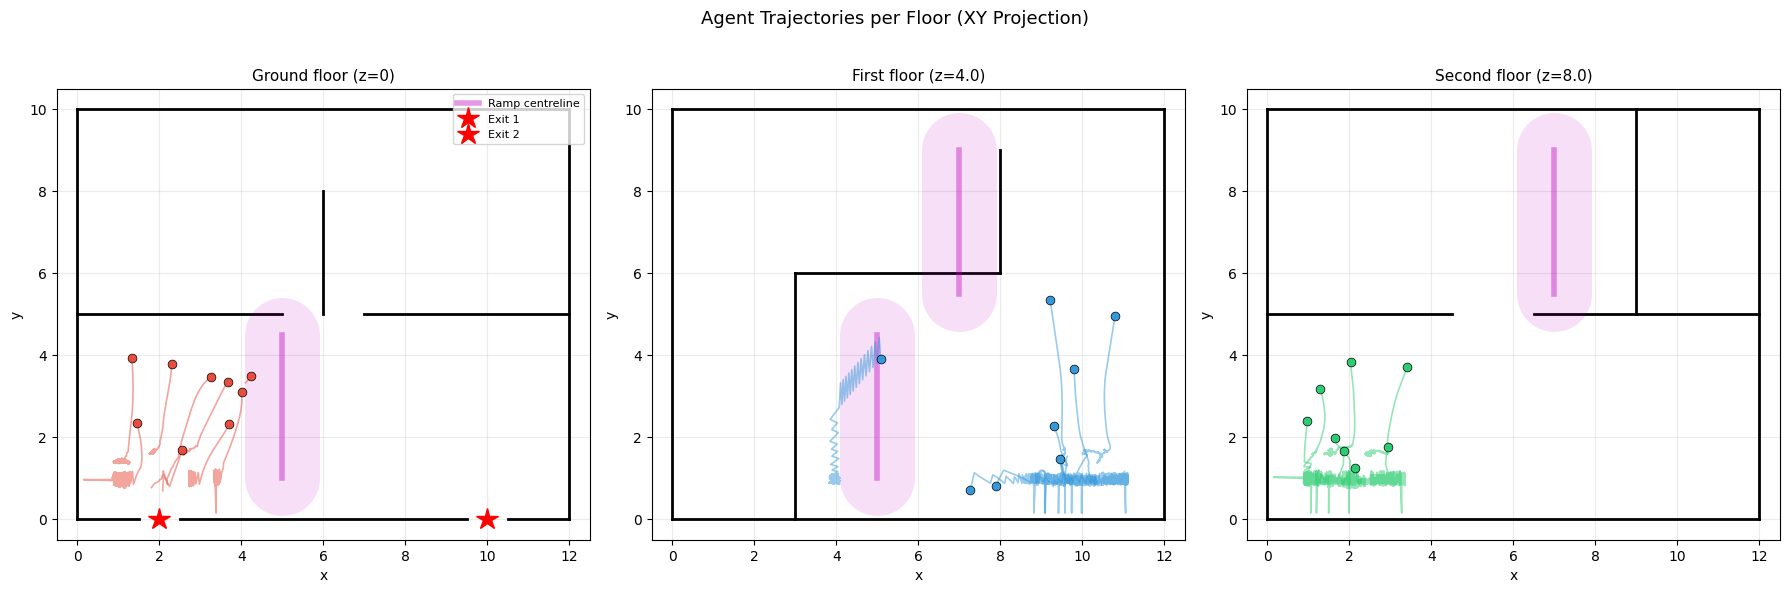

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

FLOOR_COLORS = ["#e74c3c", "#3498db", "#2ecc71"]
FLOOR_NAMES  = ["Ground floor (z=0)", f"First floor (z={H})", f"Second floor (z={2*H})"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for fl, ax in enumerate(axes):
    fz = FLOOR_Z[fl]
    ax.set_xlim(-0.5, W + 0.5)
    ax.set_ylim(-0.5, D + 0.5)
    ax.set_aspect("equal")
    ax.set_title(FLOOR_NAMES[fl], fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(True, alpha=0.25)

    # Draw floor walls
    for a, b in FLOOR_WALLS[fl]:
        ax.plot([a[0], b[0]], [a[1], b[1]], "k-", lw=2)

    # Draw ramp footprints
    for ramp in RAMPS:
        if ramp["floor_below"] == fl or ramp["floor_above"] == fl:
            A2, B2 = ramp["A"], ramp["B"]
            ax.plot([A2[0], B2[0]], [A2[1], B2[1]], "m-", lw=4, alpha=0.4,
                    label="Ramp centreline")
            # Draw capsule outline (approximate with a thick line)
            ax.plot([A2[0], B2[0]], [A2[1], B2[1]], "m-",
                    lw=ramp["r"] * 60, alpha=0.12, solid_capstyle="round")

    # Draw exits on ground floor
    if fl == 0:
        for k, ex in enumerate(EXITS):
            ax.plot(ex[0], ex[1], "r*", ms=16, zorder=8,
                    label=f"Exit {k+1}")
        ax.legend(fontsize=8, loc="upper right")

    # Draw agent trajectories for agents that started on this floor
    for i in range(N_PARTICLES):
        # Find steps where agent is roughly on this floor
        traj = history[:, i, :]
        on_floor = np.abs(traj[:, 2] - fz) < (H * 0.6)
        if not on_floor.any():
            continue
        xs = traj[on_floor, 0]
        ys = traj[on_floor, 1]
        ax.plot(xs, ys, "-", color=FLOOR_COLORS[fl], alpha=0.5, lw=1.2)
        ax.scatter(xs[0], ys[0], s=40, color=FLOOR_COLORS[fl],
                   edgecolors="black", lw=0.5, zorder=6)

plt.suptitle("Agent Trajectories per Floor (XY Projection)", fontsize=13)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/trajectories_per_floor.png", dpi=120,
            bbox_inches="tight")
plt.show()
print("Trajectory plot saved.")

---

## 6. Exit Selection Analysis

We measure how many agents chose each exit to verify that the soft-min cost
function allows natural splitting without any hard-coded assignment.

In [ ]:
def assigned_exit(final_pos, exits, tol=2.5):
    """Return 0, 1, or -1 (not evacuated) for final position."""
    for k, e in enumerate(exits):
        if np.linalg.norm(final_pos - e) < tol:
            return k
    return -1

final_positions = history[-1]
exit_counts = [0, 0, 0]   # exit0, exit1, not evacuated
for i in range(N_PARTICLES):
    k = assigned_exit(final_positions[i], EXITS)
    if k >= 0:
        exit_counts[k] += 1
    else:
        exit_counts[2] += 1

print("\nExit selection summary:")
print(f"  Exit 1 (SW): {exit_counts[0]} agents")
print(f"  Exit 2 (SE): {exit_counts[1]} agents")
print(f"  Not evacuated (still inside): {exit_counts[2]} agents")

fig2, ax2 = plt.subplots(figsize=(5, 4))
bars = ax2.bar(["Exit 1 (SW)", "Exit 2 (SE)", "Not evacuated"],
               exit_counts, color=["#e74c3c", "#3498db", "#95a5a6"])
ax2.set_ylabel("Number of agents")
ax2.set_title("Exit Selection — Soft-Min Goal Cost (τ = {})".format(TAU))
for bar, val in zip(bars, exit_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             str(val), ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/exit_selection.png", dpi=120,
            bbox_inches="tight")
plt.show()
print("Exit selection chart saved.")


---

## 7. 3-D Building Visualization and Animation (vedo)

We use the **vedo** library to produce a high-quality 3-D rendering of the
building and the animated evacuation.  The building consists of:
* Semi-transparent floor slabs
* Short interior wall boxes
* Taller back/outer walls
* Ramp surface meshes
* Coloured agent spheres

In [ ]:
try:
    import vedo
    from vedo import (Plotter, Sphere, Box, Line, Mesh, Points,
                      Cylinder, Cone, Text2D)
    from vedo.shapes import Rectangle
    VEDO_AVAILABLE = True
    print("vedo found — 3-D rendering enabled.")
    vedo.settings.default_backend = "vtk"
except ImportError:
    VEDO_AVAILABLE = False
    print("vedo not installed.  Run:  !pip install vedo")

In [ ]:
def make_floor_slab(z_floor, width=W, depth=D, thickness=0.15, color="#d4c5a9"):
    """Return a thin Box representing a floor slab."""
    slab = Box(pos=(width/2, depth/2, z_floor - thickness/2),
               length=width, width=depth, height=thickness)
    slab.c(color).alpha(0.35).lighting("ambient")
    return slab


def make_wall_box(a2, b2, z_floor, wall_height=1.8, thickness=0.2,
                  color="#b0b0b0"):
    """
    Return a Box for a wall segment defined by 2-D endpoints a2, b2
    at the given floor z.
    """
    a2, b2 = np.array(a2, float), np.array(b2, float)
    mid = (a2 + b2) / 2.0
    length = np.linalg.norm(b2 - a2)
    if length < 1e-6:
        return None
    angle_deg = np.degrees(np.arctan2(b2[1] - a2[1], b2[0] - a2[0]))
    box = Box(pos=(mid[0], mid[1], z_floor + wall_height / 2),
              length=length, width=thickness, height=wall_height)
    box.rotate_z(angle_deg)
    box.c(color).alpha(0.80).lighting("plastic")
    return box


def make_ramp_mesh(ramp, n_along=20, n_across=8):
    """
    Build a vedo Mesh for a ramp surface patch.
    The patch is a parallelogram swept along the centreline direction,
    extended by ±r_ramp perpendicular to the centreline.
    """
    A, B = ramp["A"], ramp["B"]
    z0, z1 = ramp["z0"], ramp["z1"]
    r = ramp["r"]

    v = B - A
    length = np.linalg.norm(v)
    v_hat = v / length
    perp = np.array([-v_hat[1], v_hat[0]])  # 90° CCW

    verts = []
    faces = []

    for j in range(n_along + 1):
        u = j / n_along
        centre_2d = A + u * v
        z_centre = z0 + (z1 - z0) * u
        for k in range(n_across + 1):
            w = (k / n_across - 0.5) * 2 * r   # in [-r, +r]
            xy = centre_2d + w * perp
            verts.append([xy[0], xy[1], z_centre])

    # Quad faces
    for j in range(n_along):
        for k in range(n_across):
            i0 = j * (n_across + 1) + k
            i1 = i0 + 1
            i2 = i0 + (n_across + 1)
            i3 = i2 + 1
            faces.append([i0, i1, i3])
            faces.append([i0, i3, i2])

    mesh = Mesh([verts, faces])
    mesh.c("#c8a96e").alpha(0.85).lighting("plastic")
    return mesh


def build_3d_scene():
    """
    Return a list of vedo objects forming the static 3-D building.
    """
    objects = []

    # ── Floor slabs ───────────────────────────────────────────────────────────
    slab_colors = ["#c8b89a", "#a8c5d8", "#c8d8a8"]
    for fl, (fz, col) in enumerate(zip(FLOOR_Z, slab_colors)):
        objects.append(make_floor_slab(fz, color=col))

    # ── Walls ─────────────────────────────────────────────────────────────────
    for fl, fz in enumerate(FLOOR_Z):
        for idx, (a, b) in enumerate(FLOOR_WALLS[fl]):
            # Outer walls taller; interior walls shorter
            is_outer = (idx < 4)
            h = 2.8 if is_outer else 1.6
            col = "#909090" if is_outer else "#b8b8b8"
            w_box = make_wall_box(a, b, fz, wall_height=h, color=col)
            if w_box is not None:
                objects.append(w_box)

    # ── Ramps ─────────────────────────────────────────────────────────────────
    for ramp in RAMPS:
        objects.append(make_ramp_mesh(ramp))

    # ── Exit markers ──────────────────────────────────────────────────────────
    for k, ex in enumerate(EXITS):
        col = "#e74c3c" if k == 0 else "#e67e22"
        cone = Cone(pos=(ex[0], ex[1], 0.3), r=0.4, height=0.8,
                    axis=(0, 0, 1)).c(col).alpha(0.9)
        objects.append(cone)

    return objects


In [ ]:
def render_evacuation_video(history, exits, out_dir="frames_evac",
                             video_name="evacuation_3d.mp4", fps=20):
    """
    Render each frame of the evacuation history with vedo (offscreen)
    and stitch into an MP4 with ffmpeg.
    """
    if not VEDO_AVAILABLE:
        print("vedo not available — skipping 3-D render.")
        return

    T, N, _ = history.shape
    os.makedirs(out_dir, exist_ok=True)
    for f in glob.glob(os.path.join(out_dir, "*.png")):
        os.remove(f)

    # ── Static building objects ────────────────────────────────────────────────
    scene_objects = build_3d_scene()

    # ── Agent spheres ──────────────────────────────────────────────────────────
    # Colour by original floor
    agent_colors = []
    for i in range(N):
        fl = nearest_floor(history[0, i, 2])
        agent_colors.append(["#e74c3c", "#3498db", "#2ecc71"][fl])

    spheres = []
    for i in range(N):
        sp = Sphere(r=0.22, res=16)
        sp.pos(*history[0, i])
        sp.c(agent_colors[i]).alpha(0.92).lighting("glossy")
        spheres.append(sp)

    # ── Plotter ────────────────────────────────────────────────────────────────
    plt_v = Plotter(offscreen=True, size=(1024, 768), bg="white", axes=0)
    title_txt = Text2D("Building Evacuation — 3 Floors", pos="top-center",
                       s=0.9, c="k")

    all_objects = scene_objects + spheres + [title_txt]
    plt_v.show(all_objects, resetcam=True,
               camera=dict(pos=(25, -18, 22), focalPoint=(6, 5, 4),
                           viewup=(0, 0, 1)))

    # ── Frame loop ─────────────────────────────────────────────────────────────
    step_skip = max(1, T // 300)   # target ≤ 300 frames
    frame_counter = 0

    for frame_idx in range(0, T, step_skip):
        for i in range(N):
            spheres[i].pos(*history[frame_idx, i])
        plt_v.render()
        png_path = os.path.join(out_dir, f"frame_{frame_counter:05d}.png")
        plt_v.screenshot(png_path)
        frame_counter += 1

    plt_v.close()
    print(f"  Rendered {frame_counter} frames.")

    # ── Stitch ────────────────────────────────────────────────────────────────
    cmd = (
        f"ffmpeg -loglevel error -y -framerate {fps} "
        f"-i '{out_dir}/frame_%05d.png' "
        f"-c:v libx264 -pix_fmt yuv420p -movflags +faststart "
        f"/mnt/user-data/outputs/{video_name}"
    )
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode == 0:
        print(f"  Video saved → /mnt/user-data/outputs/{video_name}")
    else:
        print("  ffmpeg error:", result.stderr)


In [ ]:
if VEDO_AVAILABLE:
    print("\nRendering 3-D evacuation animation …")
    render_evacuation_video(history, EXITS,
                             out_dir="frames_evac",
                             video_name="evacuation_3d.mp4",
                             fps=20)
else:
    print("Install vedo to produce the 3-D animation.")

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation as manim
from IPython.display import HTML

rc_params = {"animation.html": "jshtml"}
plt.rcParams.update(rc_params)

def make_3d_animation(history, exits, interval=40, step=3):
    """Build a matplotlib 3-D FuncAnimation as a fallback."""
    T, N, _ = history.shape
    frames = range(0, T, step)

    fig = plt.figure(figsize=(12, 8))
    ax  = fig.add_subplot(111, projection="3d")
    ax.set_xlim(0, W); ax.set_ylim(0, D); ax.set_zlim(-0.5, 2*H + 1)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title("Evacuation Simulation — 3 Floors")
    ax.set_facecolor("#f8f8f8")

    # Draw floor outlines
    for fz in FLOOR_Z:
        xs = [0, W, W, 0, 0]
        ys = [0, 0, D, D, 0]
        zs = [fz] * 5
        ax.plot(xs, ys, zs, "gray", lw=1, alpha=0.5)

    # Draw walls per floor (2-D outline projected at floor z)
    for fl, fz in enumerate(FLOOR_Z):
        for a, b in FLOOR_WALLS[fl]:
            ax.plot([a[0], b[0]], [a[1], b[1]], [fz, fz], "k-", lw=1.5, alpha=0.7)

    # Draw ramp centrelines
    for ramp in RAMPS:
        A2, B2 = ramp["A"], ramp["B"]
        ax.plot([A2[0], B2[0]], [A2[1], B2[1]], [ramp["z0"], ramp["z1"]],
                "m-", lw=3, alpha=0.7, label="Ramp")

    # Draw exits
    for k, ex in enumerate(exits):
        ax.scatter(*ex, s=200, c=["red", "orange"][k], marker="*", zorder=8,
                   label=f"Exit {k+1}")

    # Agent scatter plots
    a_cols = []
    for i in range(N):
        fl = nearest_floor(history[0, i, 2])
        a_cols.append(["#e74c3c", "#3498db", "#2ecc71"][fl])

    agent_scatter = ax.scatter(history[0, :, 0], history[0, :, 1],
                               history[0, :, 2], c=a_cols, s=60, alpha=0.9)

    ax.legend(loc="upper left", fontsize=8)

    frame_list = list(frames)

    def update(frame_no):
        fi = frame_list[frame_no]
        agent_scatter._offsets3d = (history[fi, :, 0],
                                    history[fi, :, 1],
                                    history[fi, :, 2])
        ax.set_title(f"Evacuation Simulation — step {fi}")
        return (agent_scatter,)

    ani = manim.FuncAnimation(fig, update, frames=len(frame_list),
                               interval=interval, blit=False)
    plt.close(fig)
    return ani

print("\nBuilding matplotlib 3-D animation …")
ani_3d = make_3d_animation(history, EXITS, step=4)
print("Animation ready.  Display with:  HTML(ani_3d.to_jshtml())")


In [ ]:
HTML(ani_3d.to_jshtml())

---

## 8. Quantitative Analysis

### 8.1 Distance to Nearest Exit Over Time

In [ ]:
def dist_to_nearest_exit(history, exits):
    """(T, N) array — each agent's distance to its closest exit at each step."""
    T, N, _ = history.shape
    out = np.zeros((T, N))
    for t in range(T):
        for i in range(N):
            out[t, i] = min(np.linalg.norm(history[t, i] - e) for e in exits)
    return out

dists = dist_to_nearest_exit(history, EXITS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: mean distance to exit over time
ax = axes[0]
t_arr = np.arange(STEPS + 1) * DT
ax.plot(t_arr, dists.mean(axis=1), color="#2c3e50", lw=2)
ax.fill_between(t_arr, dists.min(axis=1), dists.max(axis=1),
                alpha=0.2, color="#2c3e50")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Distance to nearest exit")
ax.set_title("Mean (±range) Distance to Exit")
ax.grid(alpha=0.3)

# Panel 2: cumulative evacuees
ax = axes[1]
evacuated_per_step = np.sum(dists < EXIT_TOL, axis=1)
ax.step(t_arr, evacuated_per_step, color="#27ae60", lw=2)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Cumulative evacuees")
ax.set_title(f"Cumulative Evacuees (N={N_PARTICLES})")
ax.set_ylim(0, N_PARTICLES + 1)
ax.grid(alpha=0.3)

plt.suptitle("Evacuation Performance Metrics", fontsize=13)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/evacuation_metrics.png", dpi=120,
            bbox_inches="tight")
plt.show()
print("Metrics plot saved.")


---

## 9. Discussion

### Q1: How does the soft-min cost function enable natural exit selection?

The soft-min goal cost
$C_\text{goal}(p) = -\tau \log\!\bigl(\sum_i \exp(-\|p-p_i^\text{exit}\|^2 / \tau)\bigr)$
assigns each exit a continuous weight $w_i = \exp(-C_i/\tau) / \sum_j \exp(-C_j/\tau)$.
An agent is pulled toward whichever exit is currently closer, but the pull is smooth
everywhere — there is no discontinuity as in a hard minimum.  With $\tau = 1.0$
(moderately soft), agents near the midline split roughly 50/50 while agents clearly
closer to one exit are pulled decisively toward it.

### Q2: How do the ramps enable floor-to-floor transitions without discrete state?

The surface height $z_\text{surf}(x,y)$ transitions linearly along the ramp centreline.
The height-adherence cost $C_\text{height} = w_h(z - z_\text{surf})^2$ acts as a soft
spring pulling the agent onto the surface.  When an agent moves into the ramp footprint,
the target surface height smoothly changes from the flat floor to the inclined ramp
plane.  The gradient of $C_\text{height}$ in z drives the agent up or down accordingly.
There is no floor-state variable; the floor an agent "is on" is entirely encoded in its
continuous z coordinate.

### Q3: What role does the smoothness term play?

The smoothness penalty $C_\text{smooth} = \|p^{k+1} - p^k\|^2$ discourages large
steps.  Near the ramp transition — where the surface height gradient in z is steep —
without smoothing, an agent might overshoot vertically and oscillate.  The smoothness
term effectively acts as a momentum damper, keeping the trajectory smooth.

### Q4: Parameter sensitivity

| Parameter | Effect if too small | Effect if too large |
|-----------|--------------------|--------------------|
| $w_h$ (height weight) | Agents drift between floors | Gradient becomes stiff; slow convergence |
| $\tau$ (soft-min temp.) | Approaches hard-min; sharp boundaries | Both exits weighted equally; slow splitting |
| $w_\text{wall}$ | Agents clip through walls | Agents cannot navigate narrow corridors |
| $R_s$ (repulsion radius) | Agents overlap | Corridor throughput drops; jamming |

---

## 10. References

1. Helbing, D., & Molnár, P. (1995). Social force model for pedestrian dynamics. *Physical Review E*, 51(5), 4282–4286.
2. vedo — A python module for scientific analysis of 3D data. https://vedo.embl.es/
3. Ribeiro, E. (2026). CSE5280 Assignment: Evacuation Simulation (Three-Floor Building). Florida Institute of Technology.